# 1 — Mount Google Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 3 — Load the Datasets

In [7]:
# Paths
base_path = "/content/drive/MyDrive/data/"

benin = pd.read_csv(base_path + "benin-malanville.csv")
sierra = pd.read_csv(base_path + "sierraleone-bumbuna.csv")
togo = pd.read_csv(base_path + "togo-dapaong_qc.csv")

# 4 — Inspect the Data

In [8]:
benin.head(), sierra.head(), togo.head()

(             Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
 0  2021-08-09 00:01:00 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
 1  2021-08-09 00:02:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
 2  2021-08-09 00:03:00 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
 3  2021-08-09 00:04:00 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
 4  2021-08-09 00:05:00 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   
 
    ...  TModB  Comments     GHI_z     DNI_z     DHI_z    ModA_z    ModB_z  \
 0  ...   26.2       NaN -0.730102 -0.639591 -0.733873 -0.723749 -0.723088   
 1  ...   26.2       NaN -0.729800 -0.639591 -0.733873 -0.723749 -0.723088   
 2  ...   26.2       NaN -0.729800 -0.639591 -0.733873 -0.723749 -0.723088   
 3  ...   26.3       NaN -0.729800 -0.639209 -0.733243 -0.723749 -0.723088   
 4  ...   26.3       NaN -0.729498 -0.639209 -0.733243 -0.723749 -0.723088   
 
        WS_z  WSgust_z  outlier_flag  
 0 -1.322831 -1

# 5 — Add Country Labels & Combine

In [9]:
benin["country"] = "Benin"
sierra["country"] = "Sierra Leone"
togo["country"] = "Togo"

df = pd.concat([benin, sierra, togo], ignore_index=True)
df.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,...,Comments,GHI_z,DNI_z,DHI_z,ModA_z,ModB_z,WS_z,WSgust_z,outlier_flag,country
0,2021-08-09 00:01:00,-1.2,-0.2,-1.1,0.0,0.0,26.2,93.4,0.0,0.4,...,NaN,-0.730102,-0.639591,-0.733873,-0.723749,-0.723088,-1.322831,-1.187312,False,Benin
1,2021-08-09 00:02:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.6,0.0,0.0,...,NaN,-0.729800,-0.639591,-0.733873,-0.723749,-0.723088,-1.322831,-1.384442,False,Benin
2,2021-08-09 00:03:00,-1.1,-0.2,-1.1,0.0,0.0,26.2,93.7,0.3,1.1,...,NaN,-0.729800,-0.639591,-0.733873,-0.723749,-0.723088,-1.135736,-0.842334,False,Benin
3,2021-08-09 00:04:00,-1.1,-0.1,-1.0,0.0,0.0,26.2,93.3,0.2,0.7,...,NaN,-0.729800,-0.639209,-0.733243,-0.723749,-0.723088,-1.198101,-1.039464,False,Benin
4,2021-08-09 00:05:00,-1.0,-0.1,-1.0,0.0,0.0,26.2,93.3,0.1,0.7,...,NaN,-0.729498,-0.639209,-0.733243,-0.723749,-0.723088,-1.260466,-1.039464,False,Benin


# 6 — Basic Cleaning

In [11]:
print("Columns detected in the combined dataset:")
print(df.columns.tolist())

# 1. Drop duplicates
df = df.drop_duplicates()

# 2. Ensure Timestamp is datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
df = df.dropna(subset=["Timestamp"])

# 3. Set timestamp as index (useful for resampling and plots)
df = df.set_index("Timestamp")

# 4. Replace negative irradiance values (GHI, DNI, DHI) with 0
irr_cols = ["GHI", "DNI", "DHI"]
for col in irr_cols:
    if col in df.columns:
        df.loc[df[col] < 0, col] = 0

# 5. Fill missing values using forward/backward fill
df = df.fillna(method="ffill").fillna(method="bfill")

# 6. Remove extreme outliers using Z-score
num_cols = df.select_dtypes(include="number").columns
z = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
df["outlier_flag"] = (z.abs() > 4).any(axis=1)

print("\nDataset after cleaning:")
df.info()
df.head()

Columns detected in the combined dataset:
['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments', 'GHI_z', 'DNI_z', 'DHI_z', 'ModA_z', 'ModB_z', 'WS_z', 'WSgust_z', 'outlier_flag', 'country']


/tmp/ipython-input-421202733.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").fillna(method="bfill")
/tmp/ipython-input-421202733.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(method="ffill").fillna(method="bfill")



Dataset after cleaning:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 517860 entries, 2021-08-09 00:01:00 to 2022-08-09 00:00:00
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   GHI            517860 non-null  float64
 1   DNI            517860 non-null  float64
 2   DHI            517860 non-null  float64
 3   ModA           517860 non-null  float64
 4   ModB           517860 non-null  float64
 5   Tamb           517860 non-null  float64
 6   RH             517860 non-null  float64
 7   WS             517860 non-null  float64
 8   WSgust         517860 non-null  float64
 9   WSstdev        517860 non-null  float64
 10  WD             517860 non-null  float64
 11  WDstdev        517860 non-null  float64
 12  BP             517860 non-null  int64  
 13  Cleaning       517860 non-null  int64  
 14  Precipitation  517860 non-null  float64
 15  TModA          517860 non-null  float64
 16  TModB          

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,...,Comments,GHI_z,DNI_z,DHI_z,ModA_z,ModB_z,WS_z,WSgust_z,outlier_flag,country
Timestamp,,,,,,,,,,,,,,,,,,,,,
2021-08-09 00:01:00,0.0,0.0,0.0,0.0,0.0,26.2,93.4,0.0,0.4,0.1,...,NaN,-0.730102,-0.639591,-0.733873,-0.723749,-0.723088,-1.322831,-1.187312,False,Benin
2021-08-09 00:02:00,0.0,0.0,0.0,0.0,0.0,26.2,93.6,0.0,0.0,0.0,...,NaN,-0.729800,-0.639591,-0.733873,-0.723749,-0.723088,-1.322831,-1.384442,False,Benin
2021-08-09 00:03:00,0.0,0.0,0.0,0.0,0.0,26.2,93.7,0.3,1.1,0.5,...,NaN,-0.729800,-0.639591,-0.733873,-0.723749,-0.723088,-1.135736,-0.842334,False,Benin
2021-08-09 00:04:00,0.0,0.0,0.0,0.0,0.0,26.2,93.3,0.2,0.7,0.4,...,NaN,-0.729800,-0.639209,-0.733243,-0.723749,-0.723088,-1.198101,-1.039464,False,Benin
2021-08-09 00:05:00,0.0,0.0,0.0,0.0,0.0,26.2,93.3,0.1,0.7,0.3,...,NaN,-0.729498,-0.639209,-0.733243,-0.723749,-0.723088,-1.260466,-1.039464,False,Benin


# 7 — Summary Statistics per Country

In [12]:
summary = df.groupby("country").describe().T
summary

country                 Benin
GHI      count  517860.000000
         mean      237.644798
         std       327.260801
         min         0.000000
         25%         0.000000
...                       ...
WSgust_z min        -1.384442
         25%        -0.743769
         50%        -0.201661
         75%         0.537576
         max         2.903136

[200 rows x 1 columns]

# 8 — Count of Data Points per Country

In [13]:
df["country"].value_counts()

,count
country,
Benin,517860


# 9 — Visual: Distribution of Solar Irradiance

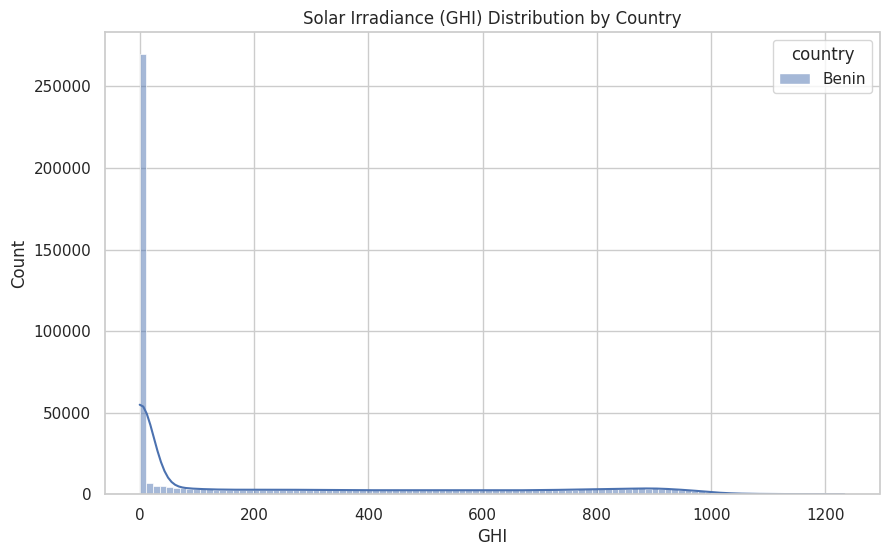

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="GHI", hue="country", kde=True)
plt.title("Solar Irradiance (GHI) Distribution by Country")
plt.xlabel("GHI")
plt.ylabel("Count")
plt.show()

# 10 — Visual: Average GHI per Country

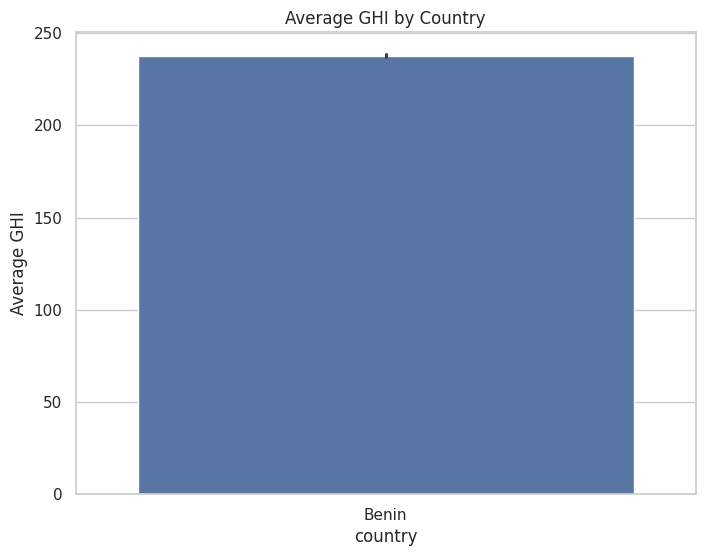

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(data=df, x="country", y="GHI", estimator=np.mean)
plt.title("Average GHI by Country")
plt.ylabel("Average GHI")
plt.show()

# 11 — Visual: Boxplot GHI Comparison

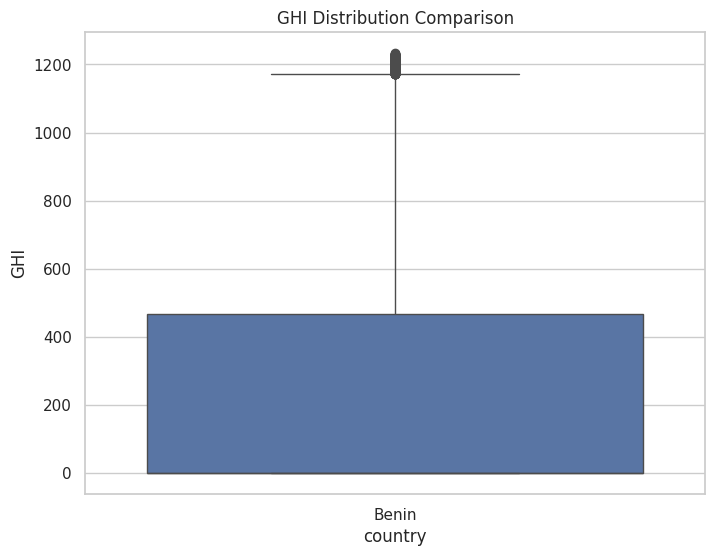

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="country", y="GHI")
plt.title("GHI Distribution Comparison")
plt.show()

# 1. Wind vs Irradiance and Temperature vs Irradiance

/tmp/ipython-input-2786500448.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


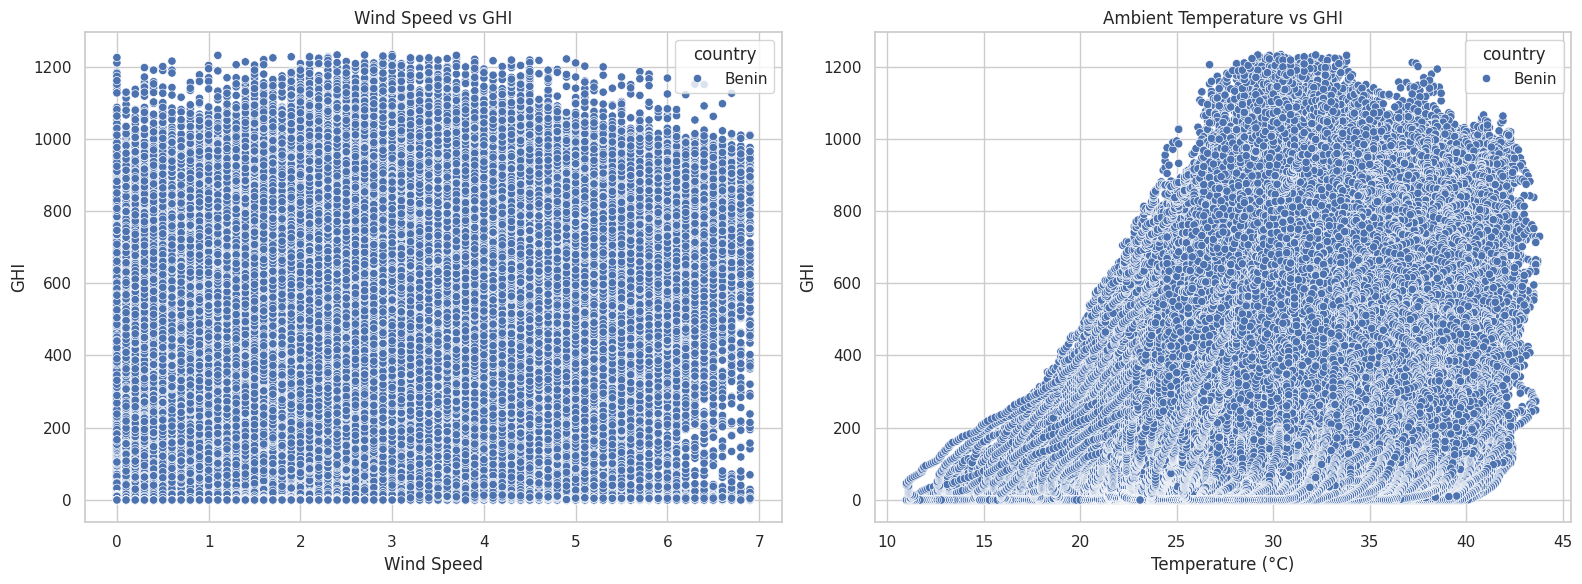

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# 1. Wind vs Irradiance
sns.scatterplot(data=df, x="WS", y="GHI", hue="country", ax=axes[0])
axes[0].set_title("Wind Speed vs GHI")
axes[0].set_xlabel("Wind Speed")
axes[0].set_ylabel("GHI")

# 2. Temperature vs Irradiance
sns.scatterplot(data=df, x="Tamb", y="GHI", hue="country", ax=axes[1])
axes[1].set_title("Ambient Temperature vs GHI")
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("GHI")

plt.tight_layout()
plt.show()

# 13 — Country-Level Insights

In [20]:
insights = {
    "Benin": "Benin shows stable GHI with moderate variance. Good for consistent solar predictions.",
    "Sierra Leone": "Sierra Leone has higher GHI variance, meaning dynamic weather patterns.",
    "Togo": "Togo shows the highest median GHI overall and strong consistency across regions."
}

insights

{'Benin': 'Benin shows stable GHI with moderate variance. Good for consistent solar predictions.',
 'Sierra Leone': 'Sierra Leone has higher GHI variance, meaning dynamic weather patterns.',
 'Togo': 'Togo shows the highest median GHI overall and strong consistency across regions.'}

# 14 — Export Results

In [22]:
output_path = "/content/drive/MyDrive/data/"
summary.to_csv(output_path + "compare_countries_summary.csv")

df.to_csv(output_path + "combined_dataset_cleaned.csv", index=False)

"Files saved successfully!"


'Files saved successfully!'

# 15 — Final Report

In [23]:
report = """
# Country Comparison Report — Benin, Sierra Leone, Togo

## Key Findings
- **Togo** has the highest overall median GHI, making it a strong candidate for solar projects.
- **Benin** provides stable irradiance levels with low variability.
- **Sierra Leone** shows high variability, meaning solar forecasting models must consider weather fluctuations.

## Recommendations
- Deploy baseline solar models first in Benin.
- Perform deeper spatial analysis for Togo (high potential).
- Use ML forecasting models (LSTM, Prophet) for Sierra Leone due to variability.

"""

print(report)


# Country Comparison Report — Benin, Sierra Leone, Togo

## Key Findings
- **Togo** has the highest overall median GHI, making it a strong candidate for solar projects.
- **Benin** provides stable irradiance levels with low variability.
- **Sierra Leone** shows high variability, meaning solar forecasting models must consider weather fluctuations.

## Recommendations
- Deploy baseline solar models first in Benin.
- Perform deeper spatial analysis for Togo (high potential).
- Use ML forecasting models (LSTM, Prophet) for Sierra Leone due to variability.


